# Image Classification with CNN (Fashion MNIST)
# Author: Patrick Emge
# 

# This project builds a Convolutional Neural Network (CNN) to classify
# clothing images into categories such as shirts, trousers, and shoes.
# The model demonstrates how deep learning can automate image classification
# for e-commerce applications.

In [105]:
# ============================================
# 1. Import Libraries
# ============================================

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Flatten
from tensorflow.keras.utils import to_categorical

# ============================================
# 2. Load Data
# ============================================

data = np.load('data/fashion_mnist.npz')

train_images = data['train_images']
train_labels = data['train_labels']
test_images = data['test_images']
test_labels = data['test_labels']

# Normalize pixel values
train_images = train_images / 255.0
test_images = test_images / 255.0

# Reshape for CNN input
train_images = train_images.reshape(-1, 28, 28, 1)
test_images = test_images.reshape(-1, 28, 28, 1)

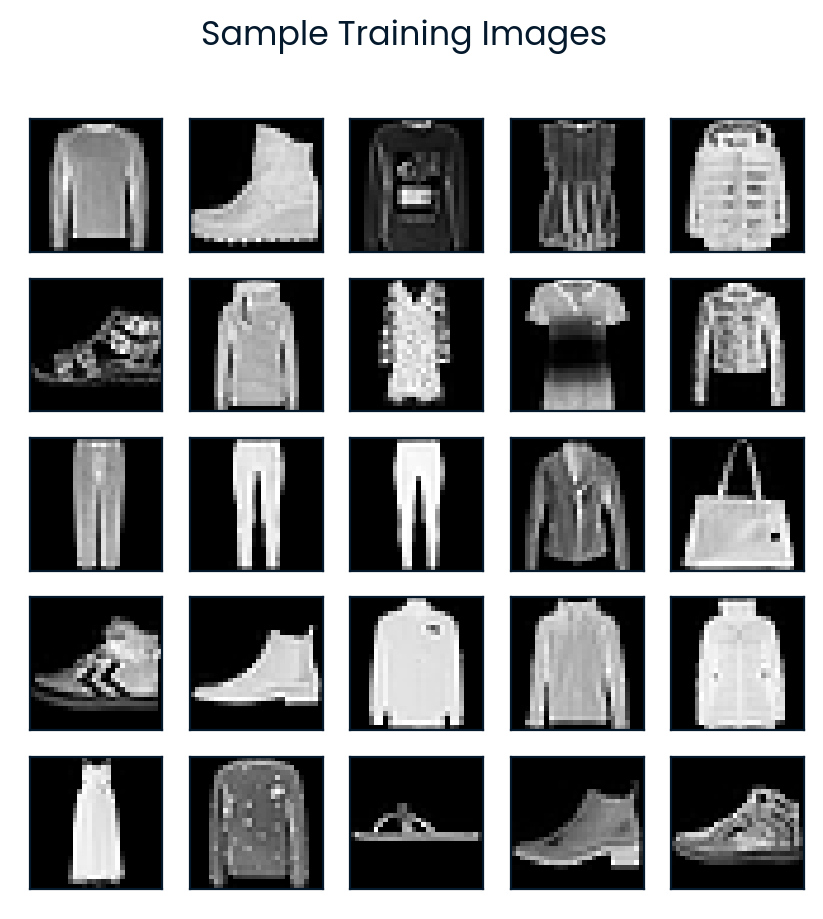

In [106]:
# ============================================
# 3. Data Visualization
# ============================================

plt.figure(figsize=(5,5))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(train_images[i].reshape(28,28), cmap='gray')

plt.suptitle("Sample Training Images")
plt.show()


In [107]:
# ============================================
# 4. Build CNN Model
# ============================================

num_classes = len(set(train_labels))

model = Sequential([
    Conv2D(32, kernel_size=3, activation='relu', input_shape=(28, 28, 1)),
    Conv2D(16, kernel_size=3, activation='relu'),
    Flatten(),
    Dense(num_classes, activation='softmax')
])

In [108]:
# ============================================
# 5. Compile Model
# ============================================

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [109]:
#Converting the labels
train_labels_cat = to_categorical(train_labels)
test_labels_cat = to_categorical(test_labels)

In [110]:
# ============================================
# 6. Train Model
# ============================================

history = model.fit(
    train_images,
    train_labels_cat,
    batch_size=100,
    epochs=1,
    validation_split=0.2
)

240/240 [==============================] - 24s 99ms/step - loss: 0.5892 - accuracy: 0.7910 - val_loss: 0.4211 - val_accuracy: 0.8570


In [111]:
# ============================================
# 7. Evaluate Model
# ============================================

test_loss, test_accuracy = model.evaluate(test_images, test_labels_cat)

print(f"Test Accuracy: {test_accuracy:.4f}")

157/157 [==============================] - 1s 5ms/step - loss: 0.4282 - accuracy: 0.8508
Test Accuracy: 0.8508


In [112]:
# This model demonstrates how CNNs extract spatial features
# from image data for classification tasks.

# Future improvements:
# - Increase epochs
# - Add pooling layers
# - Add dropout for regularization